In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.7.0+cpu'

# 1. Data - operating and loading

In [222]:
weight = 0.7
bias = 0.3

start = 0
stop = 1
step = 0.02

X = torch.arange(start, stop, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

creating a train/test split

In [223]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [12]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
    plt.figure(figsize=(10, 7))
    
    # plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    
    # plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    
    # plot the predictions if they exist
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
        
    # legend
    plt.legend(prop={"size": 14})

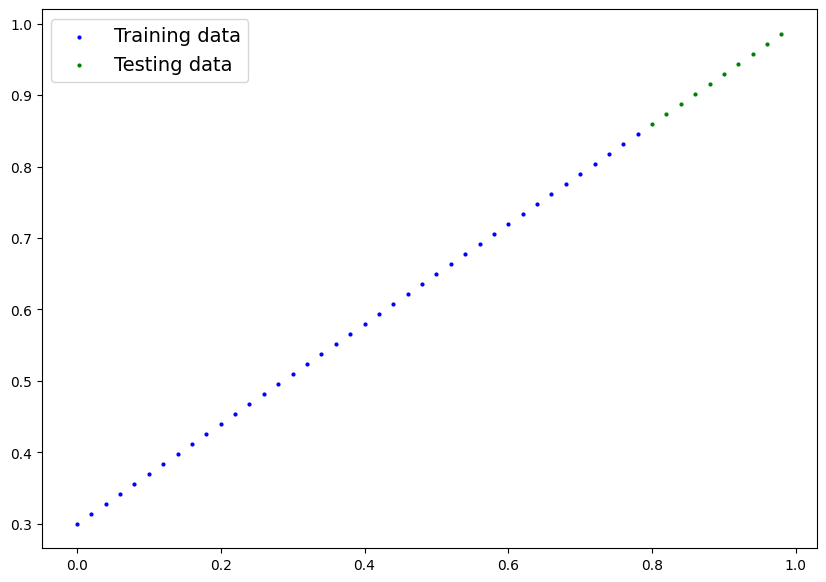

In [225]:
plot_predictions()

# 2. Building a model

In [226]:
"""
tensor = torch.randn() # randn() - generates tensor with values in a normal distribution with mean=0 and var=1
# rand() generates a tensor with random values between 0 and 1
tensor
"""

# Creating a linear regression model

class LinearRegressionModel(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        
    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias
            

In [235]:
# Checking out object parameters
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

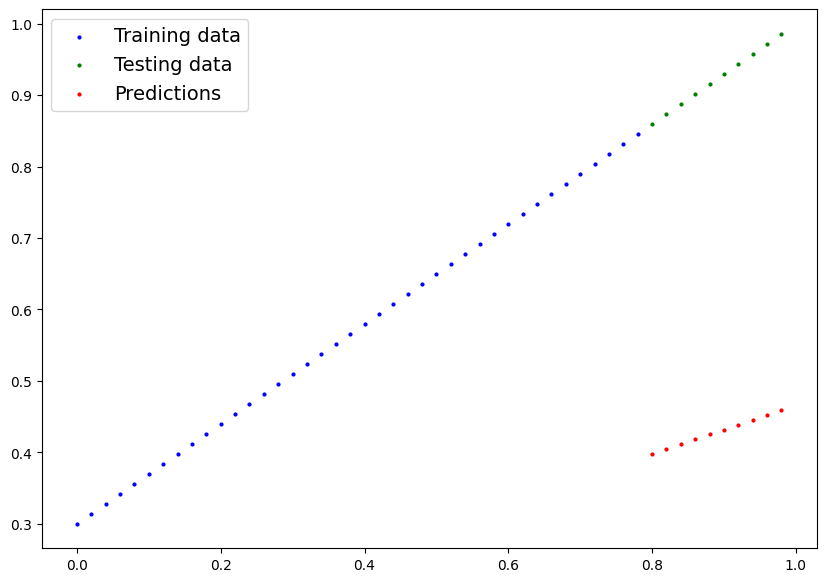

In [236]:
# Making prediction with the model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds, y_test
plot_predictions(predictions=y_preds)

# 3. Training the model

**L1 loss function** OR mean absolute error (MAE): used mainly in regression tasks
It measures the average of the absolute differences between the predicted and true values

**SGD optimizer** (stochastic gradient descent) optimization algorithm: It updates model parameters based on a subset of the training data.

In [239]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # lr - learning rate (a hyperparameter)

Building a training loop (and a testing loop)

In [ ]:
torch.manual_seed(42)

epochs = 200 # No. of loops through the data (a hyperparameter)

# Tracking different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop through the data
for epoch in range(epochs):
    model_0.train() # Set the model to training mode
    
    # 1. Forward pass
    y_pred = model_0(X_train)
    
    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)
    # print(f"Loss: {loss}")
    
    # 3. Zero the optimizer gradients
    optimizer.zero_grad()
    
    # 4. Perform backpropagation on the loss w.r.t. the parameters of the model
    loss.backward()
    
    # 5. Step the optimizer (perform gradient descent)
    optimizer.step()
    
    ### Testing
    model_0.eval() # turns off different settings in the model not needed for testing
    with torch.inference_mode(): # turns off gradient tracking & couple more things behind the scenes
        # 1. Do forward pass
        test_pred = model_0(X_test)
        
        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)
        
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.03

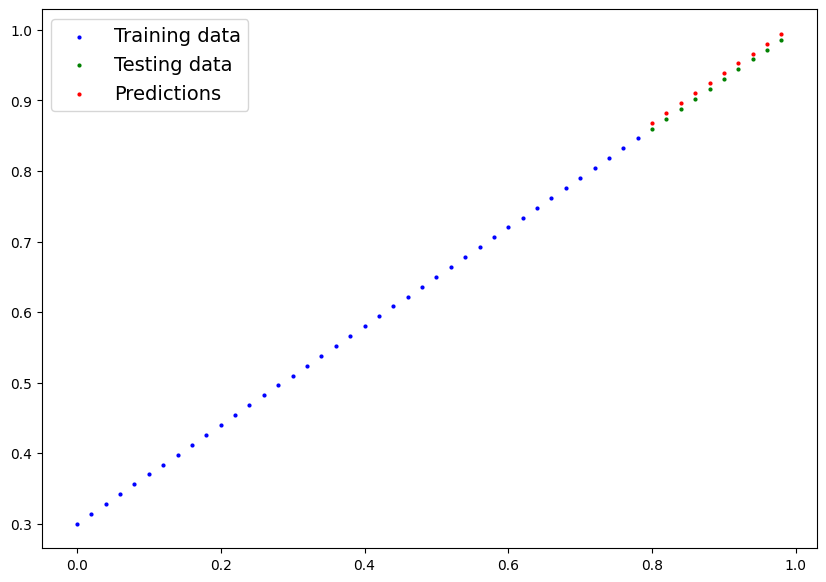

In [256]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)
    
y_preds_new

plot_predictions(predictions=y_preds_new)

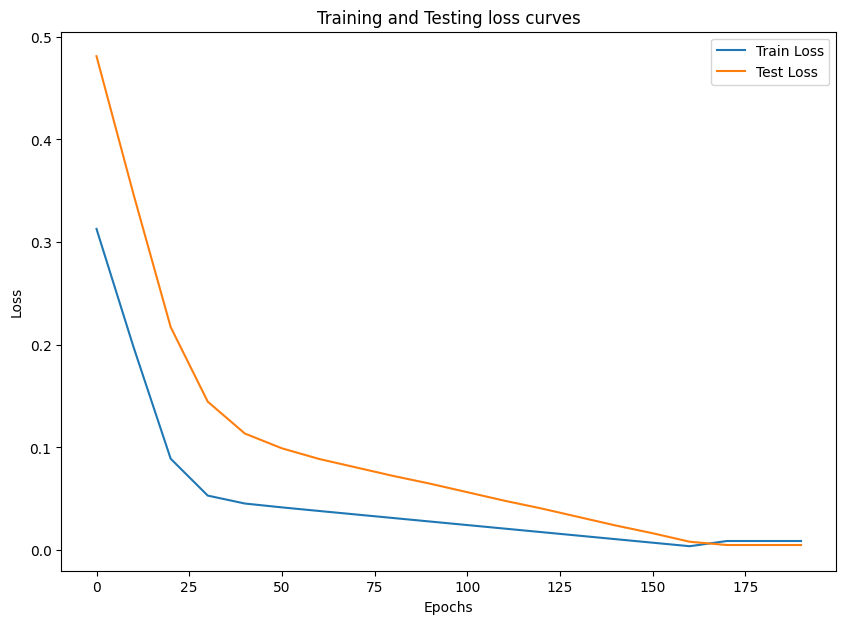

In [258]:
# Plot the loss curves
plt.figure(figsize=(10, 7))
plt.plot(torch.tensor(epoch_count), torch.tensor(loss_values), label="Train Loss")
plt.plot(torch.tensor(epoch_count), torch.tensor(test_loss_values), label="Test Loss")
plt.title("Training and Testing loss curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# 4. Saving and loading a model

In [260]:
# Saving
from pathlib import Path

# 1. Create a models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create a model save path
MODEL_NAME = "linear_regression_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\linear_regression_model_0.pth


In [262]:
# Loading

loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [263]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

# Model 2

In [9]:
# Data
weight = 0.95
bias = 0.45

start = 0
stop = 5
step = 0.05

X = torch.arange(start, stop, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]
len(X)

100

In [11]:
# Train and test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_test), len(X_train), len(y_test), len(y_train)

(20, 80, 20, 80)

In [ ]:
# Building
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1.state_dict()
    

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [33]:
# Training
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

torch.manual_seed(42)
epochs = 200
epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model_1.train()
    y_pred = model_1(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)
        
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

model_1.state_dict()

Epoch: 0 | Loss: 0.18568859994411469 | Test loss: 0.4076693058013916
Epoch: 10 | Loss: 0.15037086606025696 | Test loss: 0.2371116429567337
Epoch: 20 | Loss: 0.13486918807029724 | Test loss: 0.2083880603313446
Epoch: 30 | Loss: 0.11942975223064423 | Test loss: 0.18293523788452148
Epoch: 40 | Loss: 0.10399173200130463 | Test loss: 0.16075320541858673
Epoch: 50 | Loss: 0.08855981379747391 | Test loss: 0.1353004276752472
Epoch: 60 | Loss: 0.07311426103115082 | Test loss: 0.11311836540699005
Epoch: 70 | Loss: 0.057682327926158905 | Test loss: 0.08766539394855499
Epoch: 80 | Loss: 0.042248982936143875 | Test loss: 0.06221277639269829
Epoch: 90 | Loss: 0.02680632472038269 | Test loss: 0.04008634015917778
Epoch: 100 | Loss: 0.01847272925078869 | Test loss: 0.09609103202819824
Epoch: 110 | Loss: 0.010971629992127419 | Test loss: 0.09346656501293182
Epoch: 120 | Loss: 0.005780420266091824 | Test loss: 0.09953315556049347
Epoch: 130 | Loss: 0.008356913924217224 | Test loss: 0.09211285412311554
Ep

OrderedDict([('linear_layer.weight', tensor([[0.9492]])),
             ('linear_layer.bias', tensor([0.4598]))])

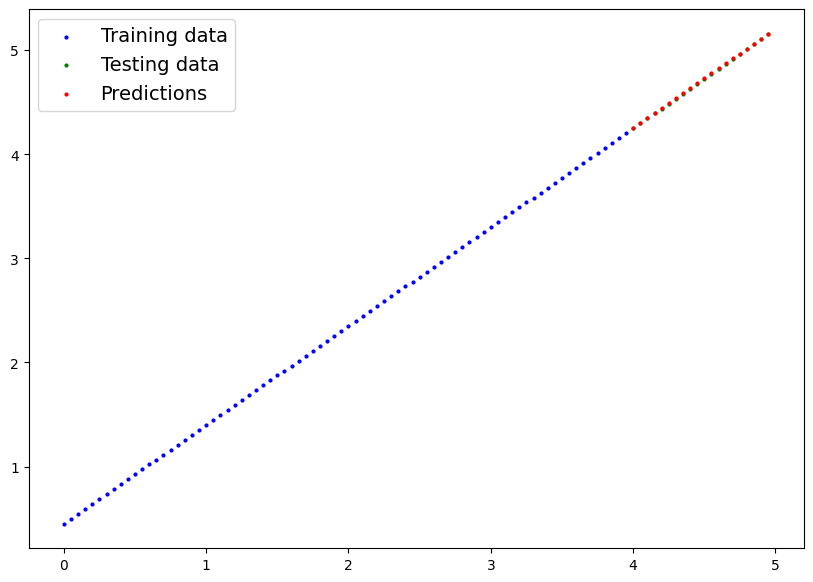

In [34]:
# Predicitions
with torch.inference_mode():
    y_preds_new = model_1(X_test)
    
plot_predictions(predictions=y_preds_new)

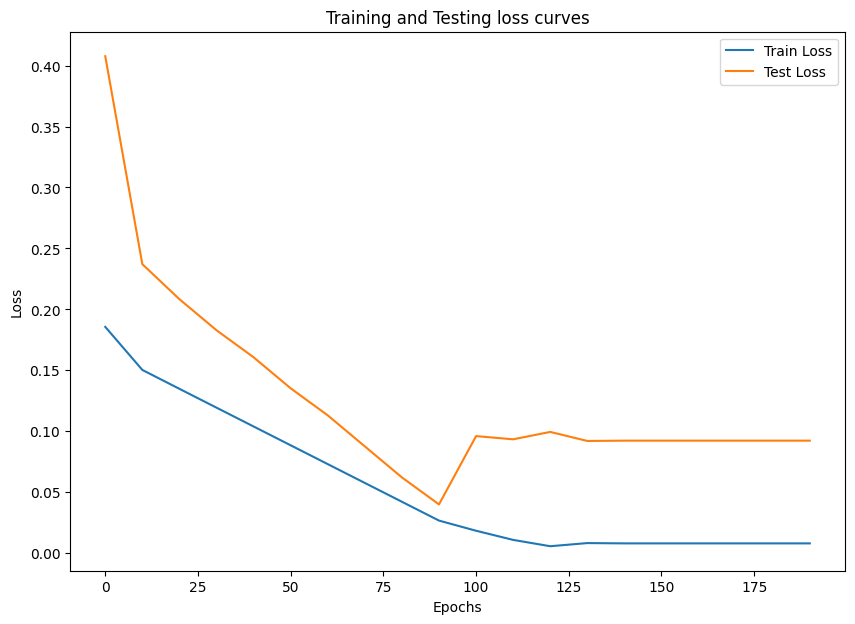

In [35]:
# Plot the loss curves
plt.figure(figsize=(10, 7))
plt.plot(torch.tensor(epoch_count), torch.tensor(loss_values), label="Train Loss")
plt.plot(torch.tensor(epoch_count), torch.tensor(test_loss_values), label="Test Loss")
plt.title("Training and Testing loss curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [38]:
# Saving
from pathlib import Path

# 1. Create a models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create a model save path
MODEL_NAME = "linear_regression_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\linear_regression_model_1.pth
